In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use('ggplot')


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Observing Training Data 

The training data contains information regarding the game title, year, a user review and a recommendation column. User recommendations are marked as "1" for recommended and "0" for otherwise. 

In [5]:
df = pd.read_csv('/Users/nick/Desktop/github_projects/train.csv')

df['user_review'] = df['user_review'].str.replace('Early Access Review', '', regex = False) 
df['user_review'] = df['user_review'].str.replace('Product received for free', '', regex = False)


In [6]:
df.head()

,review_id,title,year,user_review,user_suggestion
0,1,Spooky's Jump Scare Mansion,2016.0,I'm scared and hearing creepy voices. So I'll...,1
1,2,Spooky's Jump Scare Mansion,2016.0,"Best game, more better than Sam Pepper's YouTu...",1
2,3,Spooky's Jump Scare Mansion,2016.0,"A littly iffy on the controls, but once you kn...",1
3,4,Spooky's Jump Scare Mansion,2015.0,"Great game, fun and colorful and all that.A si...",1
4,5,Spooky's Jump Scare Mansion,2015.0,Not many games have the cute tag right next to...,1


In [7]:
df.info()

#counting number of recommended and non recommended reviews 
df['user_suggestion'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 17494 entries, 0 to 17493
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   review_id        17494 non-null  int64  
 1   title            17494 non-null  str    
 2   year             17316 non-null  float64
 3   user_review      17494 non-null  str    
 4   user_suggestion  17494 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 683.5 KB


user_suggestion
1    9968
0    7526
Name: count, dtype: int64

#
57% / 43% split. No severe class imbalance



In [8]:
unique_games = df['title'].nunique()
print(f'The dataset contains {unique_games} unique games.')

The dataset contains 44 unique games.


### Looking at most and leaast popular games in data 

Grouping the reviews by title and investigating the difference in recommendation numbers to get a broad insight into games' popularity. 

In [9]:
user_suggestion_counts = df.groupby('title')['user_suggestion'].value_counts().unstack().fillna(0)

user_suggestion_counts['difference'] = user_suggestion_counts[1] - user_suggestion_counts[0]

user_suggestion_counts['percentage'] = (user_suggestion_counts[1] / (user_suggestion_counts[1] + user_suggestion_counts[0])) * 100

user_suggestion_counts_sorted = user_suggestion_counts.sort_values(by='difference', ascending=False)

user_suggestion_counts_sorted

user_suggestion,0,1,difference,percentage
title,,,,
Fractured Space,30,688,658,95.821727
Creativerse,49,443,394,90.040650
PlanetSide 2,49,423,374,89.618644
Path of Exile,43,415,372,90.611354
Ring of Elysium,52,367,315,87.589499
Brawlhalla,55,355,300,86.585366
DCS World Steam Edition,94,394,300,80.737705
Spooky's Jump Scare Mansion,41,321,280,88.674033
Team Fortress 2,114,365,251,76.200418


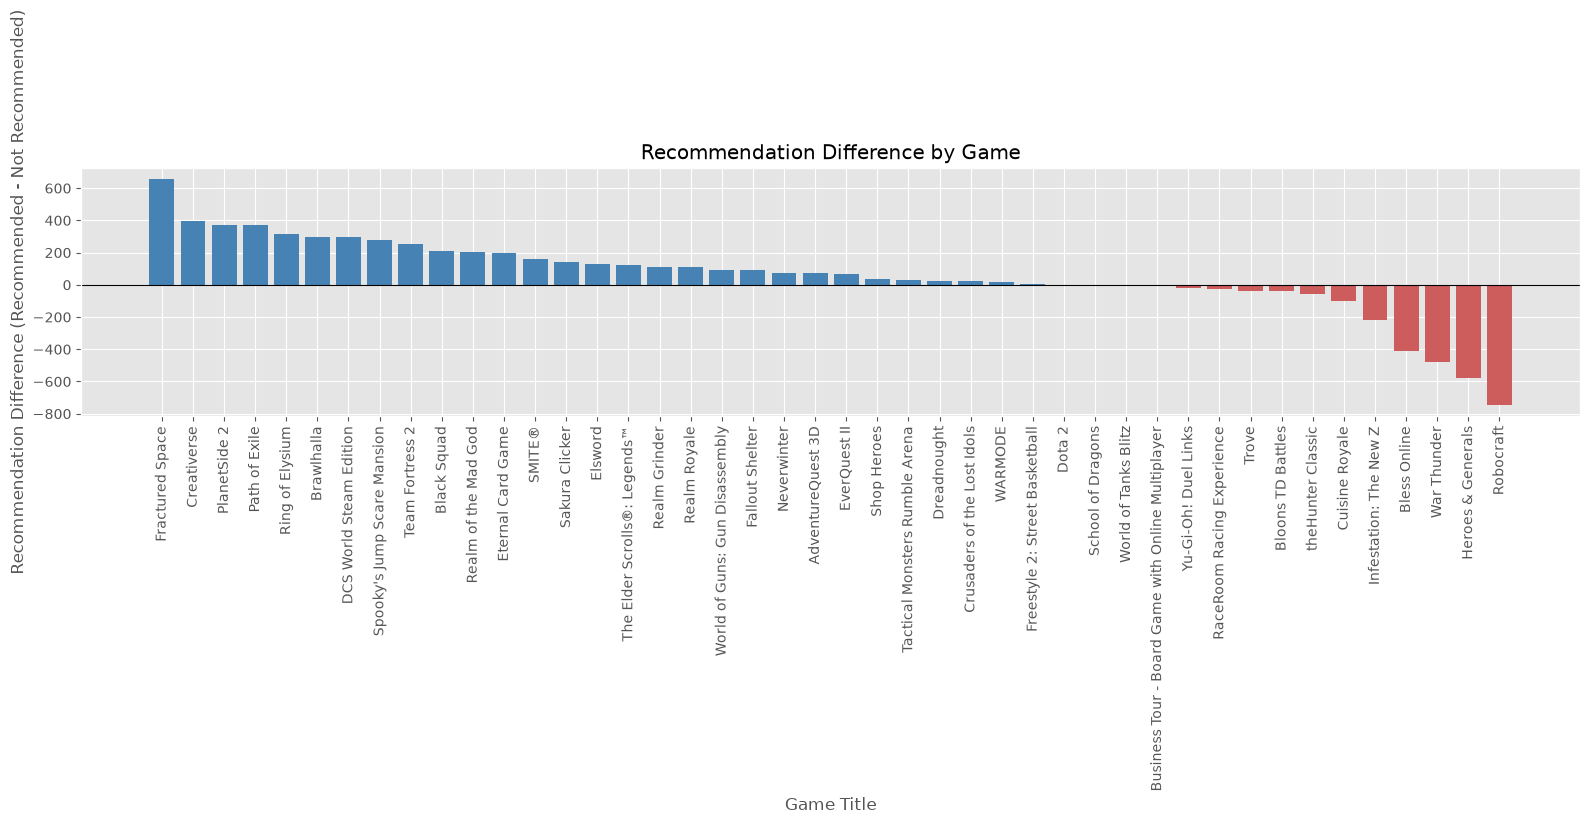

In [10]:
plt.figure(figsize=(16, 7))

# Blue for positive recommendation difference, red for negative
colors = [
    'steelblue' if value >= 0 else 'indianred'
    for value in user_suggestion_counts_sorted['difference']
]

plt.bar(
    user_suggestion_counts_sorted.index,
    user_suggestion_counts_sorted['difference'],
    color=colors
)

# Reference line at zero
plt.axhline(0, color='black', linewidth=0.8)

plt.xlabel('Game Title')
plt.ylabel('Recommendation Difference (Recommended - Not Recommended)')
plt.title('Recommendation Difference by Game')

# Rotate game titles so they remain readable
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [11]:
# Display the 5 best titles
print("5 Best Titles Based on User Suggestions:")
display(user_suggestion_counts_sorted.head(5))

# Display the 5 worst titles
print("\n5 Worst Titles Based on User Suggestions:")
display(user_suggestion_counts_sorted.tail(5))

5 Best Titles Based on User Suggestions:


user_suggestion,0,1,difference,percentage
title,,,,
Fractured Space,30,688,658,95.821727
Creativerse,49,443,394,90.040650
PlanetSide 2,49,423,374,89.618644
Path of Exile,43,415,372,90.611354
Ring of Elysium,52,367,315,87.589499



5 Worst Titles Based on User Suggestions:


user_suggestion,0,1,difference,percentage
title,,,,
Infestation: The New Z,350,129,-221,26.931106
Bless Online,561,151,-410,21.207865
War Thunder,598,122,-476,16.944444
Heroes & Generals,663,82,-581,11.006711
Robocraft,794,48,-746,5.700713


In [12]:
#Defining our inputs/outputs 

X = df['user_review'] 
y = df['user_suggestion']

In [13]:
#Splitting the dataset into training and testing sets 
#This essentially means that 80% of the data will be used for training the model, and 20% will be used for testing its performance. The random_state parameter ensures that the split is reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Converting with TF-IDF 

This is where NLP comes into play. 

In [14]:
tfidf = TfidfVectorizer(lowercase=True, stop_words='english', max_features=10000)

In [15]:
X_train_tfidf = tfidf.fit_transform(X_train) #learn the vocabulary from the training data and transform it into a TF-IDF matrix
X_test_tfidf = tfidf.transform(X_test) #use the learned vocabulary to transform the test data into a TF-IDF matrix

In [16]:
df2 = pd.read_csv('/Users/nick/Desktop/github_projects/game_overview.csv')

In [17]:
df2.head()

,title,developer,publisher,tags,overview
0,Spooky's Jump Scare Mansion,Lag Studios,Lag Studios,"['Horror', 'Free to Play', 'Cute', 'First-Pers...",Can you survive 1000 rooms of cute terror? Or ...
1,Sakura Clicker,Winged Cloud,Winged Cloud,"['Nudity', 'Anime', 'Free to Play', 'Mature', ...",The latest entry in the Sakura series is more ...
2,WARMODE,WARTEAM,WARTEAM,"['Early Access', 'Free to Play', 'FPS', 'Multi...",Free to play shooter about the confrontation o...
3,Fractured Space,Edge Case Games Ltd.,Edge Case Games Ltd.,"['Space', 'Multiplayer', 'Free to Play', 'PvP'...",Take the helm of a gigantic capital ship and g...
4,Counter-Strike: Global Offensive,"Valve, Hidden Path Entertainment",Valve,"['FPS', 'Multiplayer', 'Shooter', 'Action', 'T...",Counter-Strike: Global Offensive (CS: GO) expa...


We deliberately do not fit TF-IDF on our test data, because otherwise information from our test set would leak into model training, resulting in data leakage 

In [18]:
#matrix shape 

print(X_train_tfidf.shape) 

# ~ 13,995 training reviews and 10,000 features (words) in the TF-IDF matrix

(13995, 10000)


In [19]:
nb_model = MultinomialNB() 

nb_model.fit(X_train_tfidf, y_train) #train the model using the training data

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[6053.,7942.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.84,-0.57]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 10000)","[[10.56,11.01, 1.24,..., 0.48, 0.51, 0.51], [ 3.91, 7.52, 0.37,..., 0. , 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 10000)","[[ -8.27, -8.23, -9.91,...,-10.32,-10.3 ,-10.3 ], [ -9.32, -8.77,-10.59,...,-10.91,-10.91,-10.91]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [20]:
# Predict recommendation labels for unseen test reviews
y_pred = nb_model.predict(X_test_tfidf)

# Look at the first 10 predictions
print(y_pred[:10])

[0 0 1 1 1 0 1 1 1 1]


In [21]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Naive Bayes Accuracy: {accuracy:.2%}")

Naive Bayes Accuracy: 83.82%


In [22]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Recommended', 'Recommended']
))

                 precision    recall  f1-score   support

Not Recommended       0.86      0.73      0.79      1473
    Recommended       0.83      0.91      0.87      2026

       accuracy                           0.84      3499
      macro avg       0.84      0.82      0.83      3499
   weighted avg       0.84      0.84      0.84      3499



### The results show 

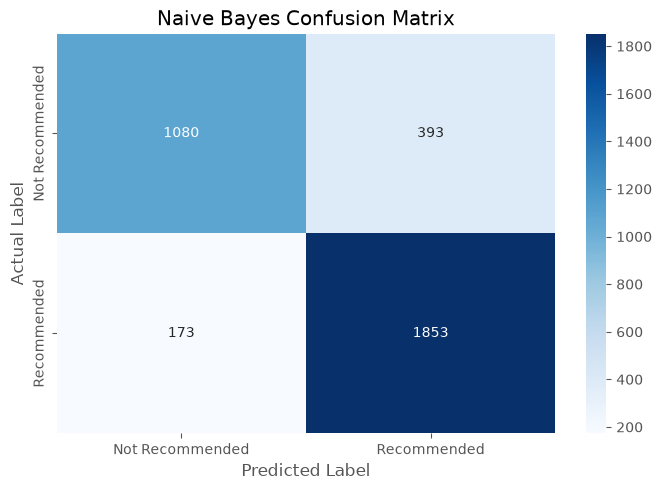

In [23]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Recommended', 'Recommended'],
    yticklabels=['Not Recommended', 'Recommended']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Naive Bayes Confusion Matrix')

plt.tight_layout()
plt.show()

In [24]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [25]:
from wordcloud import WordCloud

In [26]:
feature_names = tfidf.get_feature_names_out() 
nb_model.feature_log_prob_ 

print(nb_model.feature_log_prob_.shape)
print(nb_model.classes_)

(2, 10000)
[0 1]


In [27]:
log_prob_difference = (
    nb_model.feature_log_prob_[1]
    - nb_model.feature_log_prob_[0]
)

In [28]:
top_n = 20

# Most associated with Recommended
recommended_indices = np.argsort(log_prob_difference)[-top_n:][::-1]

# Most associated with Not Recommended
not_recommended_indices = np.argsort(log_prob_difference)[:top_n]

recommended_words = feature_names[recommended_indices]
recommended_scores = log_prob_difference[recommended_indices]

not_recommended_words = feature_names[not_recommended_indices]
not_recommended_scores = log_prob_difference[not_recommended_indices]

In [31]:
print("Words most associated with Recommended:")
print(recommended_words)

print("\nWords most associated with Not Recommended:")
print(not_recommended_words)

Words most associated with Recommended:
['smash' 'diablo' 'arpg' 'creativerse' 'minecraft' 'bros' 'ships' 'ship'
 'brawlhalla' 'exile' 'fractured' 'deca' 'highly' 'poe' 'addictive'
 'blueprints' 'intense' 'hats' 'loving' 'scary']

Words most associated with Not Recommended:
['freejam' 'gaijin' 'robocraft' 'robits' 'crate' 'uninstalling' 'refund'
 'ruined' 'garbage' 'unplayable' 'rp' 'megabots' 'robot' 'uninstalled'
 'disconnected' 'greed' 'crates' 'fj' 'infuriating' 'deleted']


In [33]:
#now for testing dataset 
test_df = pd.read_csv('test.csv')

test_df['user_review'] = test_df['user_review'].str.replace("Early Access Review", "", regex=False)
test_df['user_review'] = test_df['user_review'].str.replace("Product received for free", "", regex=False)

In [35]:
test_df.head()

,review_id,title,year,user_review
0,1603,Counter-Strike: Global Offensive,2015.0,"Nice graphics, new maps, weapons and models. B..."
1,1604,Counter-Strike: Global Offensive,2018.0,I would not recommend getting into this at its...
2,1605,Counter-Strike: Global Offensive,2018.0,Edit 11/12/18I have tried playing CS:GO recent...
3,1606,Counter-Strike: Global Offensive,2015.0,The game is great. But the community is the wo...
4,1607,Counter-Strike: Global Offensive,2015.0,I thank TrulyRazor for buying this for me a lo...


In [36]:
X_external = test_df['user_review']

# Transform reviews using the EXISTING TF-IDF vectorizer
X_external_tfidf = tfidf.transform(X_external)

# Predict recommendation using the trained Naive Bayes model
nb_test_pred = nb_model.predict(X_external_tfidf)

print(nb_test_pred[:20])

[0 0 0 0 1 1 1 1 1 0 1 1 0 1 1 0 1 0 0 1]


In [37]:
test_df['nb_prediction'] = nb_test_pred

test_df[
    ['review_id', 'title', 'user_review', 'nb_prediction']
].head(10)

,review_id,title,user_review,nb_prediction
0,1603,Counter-Strike: Global Offensive,"Nice graphics, new maps, weapons and models. B...",0
1,1604,Counter-Strike: Global Offensive,I would not recommend getting into this at its...,0
2,1605,Counter-Strike: Global Offensive,Edit 11/12/18I have tried playing CS:GO recent...,0
3,1606,Counter-Strike: Global Offensive,The game is great. But the community is the wo...,0
4,1607,Counter-Strike: Global Offensive,I thank TrulyRazor for buying this for me a lo...,1
5,1608,Counter-Strike: Global Offensive,It is kind of hard to say I do not like the ga...,1
6,1609,Counter-Strike: Global Offensive,"Since an old fan of Halo games i find, CS:GO a...",1
7,1610,Counter-Strike: Global Offensive,Hepimiz küçüklüğümüzde Counter Strike oyunları...,1
8,1611,Counter-Strike: Global Offensive,Death is a great teacher. Failure in Counter-S...,1
9,1612,Counter-Strike: Global Offensive,One of the worst communities in gaming. Griefe...,0


In [38]:
test_df['nb_label'] = test_df['nb_prediction'].map({
    0: 'Not Recommended',
    1: 'Recommended'
})

test_df[
    ['title', 'user_review', 'nb_label']
].head(10)

nb_probabilities = nb_model.predict_proba(X_external_tfidf)

test_df['nb_probability_not_recommended'] = nb_probabilities[:, 0]
test_df['nb_probability_recommended'] = nb_probabilities[:, 1]


In [39]:
test_df[
    [
        'title',
        'user_review',
        'nb_label',
        'nb_probability_recommended'
    ]
]

,title,user_review,nb_label,nb_probability_recommended
0,Counter-Strike: Global Offensive,"Nice graphics, new maps, weapons and models. B...",Not Recommended,0.488858
1,Counter-Strike: Global Offensive,I would not recommend getting into this at its...,Not Recommended,0.096930
2,Counter-Strike: Global Offensive,Edit 11/12/18I have tried playing CS:GO recent...,Not Recommended,0.196111
3,Counter-Strike: Global Offensive,The game is great. But the community is the wo...,Not Recommended,0.219419
4,Counter-Strike: Global Offensive,I thank TrulyRazor for buying this for me a lo...,Recommended,0.870034
...,...,...,...,...
8040,GUNS UP!,"Guns UP!Positive: Good Idea, addicting and lot...",Recommended,0.764599
8041,GUNS UP!,"After 170 hrs, my review. DO NOT SPEND ANY MON...",Not Recommended,0.392096
8042,GUNS UP!,Pros:-Fun GameplayCons: -Micro %$#*ing transac...,Not Recommended,0.426617
8043,GUNS UP!,"Actualy saucy, I definetly suggest to players ...",Recommended,0.775511


In [40]:
nb_predictions = test_df[
    ['review_id', 'nb_prediction', 'nb_label', 'nb_probability_recommended']
]

nb_predictions.to_csv(
    'nb_test_predictions.csv',
    index=False
)